#### **Regime 기반 Value–Momentum 동적 자산배분 전략**

- 코스피+코스닥 유니버스에서 value와 quality 팩터를 구성하고,
KOSPI200의 12개월 이동평균과 6개월 모멘텀을 기준으로 시장 레짐을 판단하여
팩터 간 비중을 동적으로 조정하는 자산배분 전략 



---
#### **라이브러리 import 및 데이터 로드**
- Pandas, Numpy 라이브러리 import
- 수정주가, 시가총액, PBR 데이터 불러오기

In [1]:
# 라이브러리 import
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

# 수정주가, 시가총액, PBR 데이터 불러오기, 'Date' 열을 인덱스, datetime 형식으로 설정
price_df = pd.read_csv('/Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/Value_quality전략/수정주가.csv', index_col = 'Date', parse_dates = True)
marketcap_df = pd.read_csv('/Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/Value_quality전략/시가총액 (1).csv', index_col = 'Date', parse_dates = True)
PBR_df = pd.read_csv('/Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/Value_quality전략/PBR (1).csv', index_col = 'Date', parse_dates = True)                     #일별 데이터 lag 필요 없음
ROE_df = pd.read_csv('/Users/hominshin/Desktop/퀀티파이_운영지원팀_메인세션/Value_quality전략/ROE_분기 (2).csv',index_col = 'Date', parse_dates = True )                 #월별 분기데이터 lag 3개월

In [2]:
ROE_df

,삼성전자,SK하이닉스,현대차,LG에너지솔루션,한화에어로스페이스,삼성바이오로직스,SK스퀘어,두산에너빌리티,기아,HD현대중공업,...,연합과기,차이나그레이트,중국원양자원,중국식품포장,에스앤씨엔진그룹,차이나하오란,웨이포트,성융광전투자유한공사,완리,골든센츄리
Date,,,,,,,,,,,,,,,,,,,,,
2014-12-31,14.71,26.98,12.83,NaN,-7.06,NaN,NaN,-1.10,14.01,NaN,...,NaN,6.37,-21.51,NaN,4.84,8.60,-38.94,NaN,15.17,NaN
2015-01-31,12.65,28.43,12.57,NaN,-6.29,NaN,NaN,-2.43,13.97,NaN,...,NaN,6.42,-23.19,NaN,6.04,9.07,-43.36,NaN,15.24,NaN
2015-02-28,12.65,28.43,12.57,NaN,-6.29,NaN,NaN,-2.43,13.97,NaN,...,NaN,6.42,-23.19,NaN,6.04,9.07,-43.36,NaN,15.24,NaN
2015-03-31,12.65,28.43,12.57,NaN,-6.29,NaN,NaN,-2.43,13.97,NaN,...,NaN,6.42,-23.19,NaN,6.04,9.07,-43.36,NaN,15.24,NaN
2015-04-30,11.96,29.35,11.27,NaN,-7.02,NaN,NaN,-2.96,12.22,NaN,...,NaN,23.64,-16.25,NaN,8.88,9.83,-50.65,NaN,12.58,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-30,10.78,44.14,NaN,NaN,NaN,19.44,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-31,10.78,44.14,NaN,NaN,NaN,19.44,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
#### **초기 작업 및 설정**
- 월 수익률 데이터 생성
- value 팩터(PBR) 신호 정리
- quality 팩터(ROE) 신호 정리
- 레짐(regime) 판단용 KOSPI200 불러오기 
- 레짐 기준 설정(kospi200의 12개월 이동평균선 & 6개월 모멘텀)

In [3]:
#월 수익률 데이터 생성
monthly_price = price_df.resample('ME').last()
monthly_return = monthly_price.pct_change(fill_method = None)
monthly_mcap = marketcap_df.resample('ME').last()
monthly_pbr = PBR_df.resample('ME').last()
monthly_roe = ROE_df.resample('ME').last().ffill()

###########데이터 레그 안되서 추가함
monthly_roe = monthly_roe.shift(2)


#value / quality signal 
value_signal = monthly_pbr 
quality_signal = monthly_roe 

#KOSPI200 불러오기
kospi200_df = pd.read_csv('KOSPI200.csv', index_col = 'Date', parse_dates = True)
monthly_kospi200 = kospi200_df.resample('ME').last()

#레짐 설정 
kospi200_ma12 = monthly_kospi200.rolling(12).mean()

mom6 = monthly_kospi200 / monthly_kospi200.shift(6) - 1  

regime = ((monthly_kospi200 > kospi200_ma12) & (mom6 > 0)).astype(int) #astype은 True일 때 1, False일 때 0 
# risk-on(regime = 1): 다중팩터 100% 
# risk-off(regime = 0): 다중팩터 30% + 현금 70%
# mom6 > 0 : 지금이 6개월 전 KOSPI200 보다 높은지


---
#### **종목 추출 및 수익률 계산**

- 10개월 이동평균이 생기는 시점부터 리밸런싱 시작 
- 레짐에 따른 비중 결정
- 모멘텀 종목 추출
- 밸류 종목 추출
- 최종 포트폴리오 수익률 

In [4]:
# 백테스팅 기간 설정
start_point = '2014-12-31'
end_point = '2025-12-31'

# 결과를 저장할 Series
portfolio_ret = pd.Series(index=monthly_kospi200.index, dtype='float64')

# 12개월 이동평균이 생기는 시점부터 리밸런싱 시작
month_ends = regime.loc[start_point:end_point].dropna().index

for i in range(len(month_ends) - 1):
    start_date = month_ends[i]
    end_date = month_ends[i + 1]

    # 1) 유니버스: 코스피 + 코스닥 중 상위 20개 기업, 하위 20% 기업 제거
    start_date_mkt_cap = monthly_mcap.loc[start_date].dropna()
    # 시총 순위 (1 = 가장 큼)
    mcap_rank = start_date_mkt_cap.rank(ascending=False, method='first')

    # 초대형주 상위 20개 제외 + 초소형주 하위 20% 제외
    lower_cut = len(mcap_rank) * 0.8

    uni = mcap_rank[(mcap_rank > 20) & (mcap_rank <= lower_cut)].index

    # 2) PBR / ROE 데이터 정리
    pbr_filtered = value_signal.loc[start_date, uni].dropna()
    pbr_filtered = pbr_filtered[pbr_filtered >= 0.2]   #PBR < 0.2 제거
    
    roe_filtered = quality_signal.loc[start_date, uni].dropna()

    # 3) 공통 종목만 사용(PBR, ROE 데이터가 존재하는 기업들)
    common = pbr_filtered.index.intersection(roe_filtered.index)

    if len(common) == 0:
        continue

    # 4) 다중팩터 점수 계산
    # PBR 낮을수록 좋음 → ascending=True
    # ROE 높을수록 좋음 → ascending=False
    # ROE 높은 집단 중에서 저 PBR
    quality_top = roe_filtered.loc[common].nlargest(80).index
    basket = pbr_filtered.loc[quality_top].nsmallest(15).index


    # 5) 선택된 종목들의 월 수익률 계산(15개중에서 변동성에 따라 가중치 다르게 부여)
    
    # 최근 1년 간의 변동성 계산
    vol = monthly_return.loc[:start_date, basket].tail(12).std()

    # inverse volatility weight
    weights = 1 / vol

    # 정규화
    weights = weights / weights.sum()

    # 포트폴리오 수익률 계산
    stock_return = (monthly_return.loc[end_date, basket] * weights).sum()

    # 6) 레짐에 따른 비중 적용
    
        # risk-on: 다중팩터 100%
    if regime.loc[start_date].item() == 1:
        portfolio_ret.loc[end_date] = stock_return
    else:
        # risk-off: 다중팩터 30% + cash 70%
        portfolio_ret.loc[end_date] = 0.3 * stock_return

portfolio_ret = portfolio_ret.dropna()

#### **포트폴리오 NAV 계산 및 그래프 출력**

In [5]:
#1) 포트폴리오 NAV 계산 
actual_rets = portfolio_ret
actual_rets.iloc[0] = 0
nav = (1 + actual_rets).cumprod()
nav 

Date
2015-03-31    1.000000
2015-04-30    1.018399
2015-05-31    1.003870
2015-06-30    0.986182
2015-07-31    1.003880
                ...   
2025-08-31    2.741004
2025-09-30    2.808343
2025-10-31    2.785106
2025-11-30    2.879092
2025-12-31    2.850945
Freq: ME, Length: 130, dtype: float64

<Axes: xlabel='Date'>

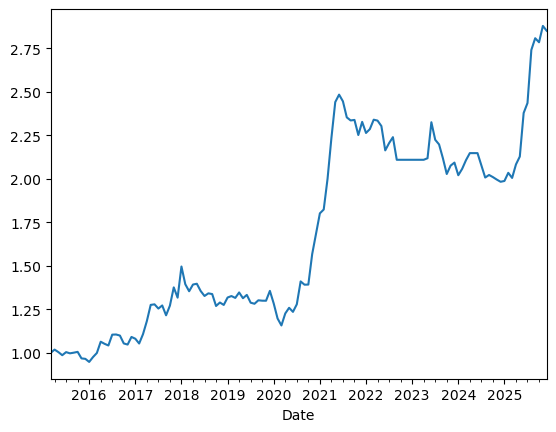

In [6]:
#2) 포트폴리오 NAV 시각화 
nav.plot()

#### **벤치마크 비교(KOSPI200)**

<Axes: xlabel='Date'>

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/

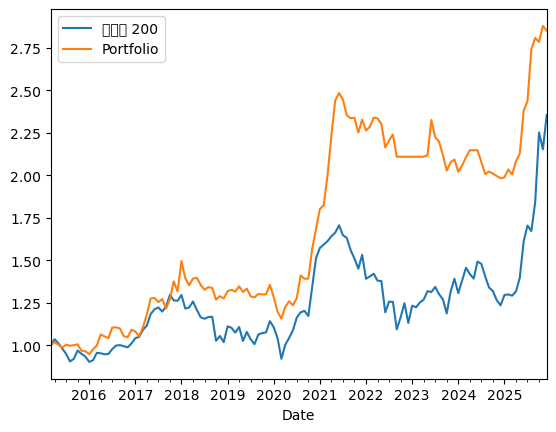

In [7]:
# 1) 포트폴리오 데이터와 Index 맞추기
monthly_kospi200 = monthly_kospi200.loc[nav.index]

# 2) 포트폴리오 NAV와 초기값 통일
monthly_kospi200 = (monthly_kospi200 / monthly_kospi200.iloc[0]) * nav.iloc[0]

# 3) 코스피200와 포트폴리오 데이터 병합
monthly_kospi200['Portfolio'] = nav

# 4) 포트폴리오 NAV와 코스피200 시각화
monthly_kospi200.plot()

#### **성과 지표 계산**

In [8]:
portfolio_ret = portfolio_ret[1:]

In [9]:
#CAGR 계산 
years = (nav.index[-1]-nav.index[0]).days/365.25
cagr = (nav.iloc[-1]/nav.iloc[0]) ** (1/years) - 1
print(f"CAGR: {cagr:.2%}")

#연 환산 변동성 계산 
volatility = portfolio_ret.std() * np.sqrt(12)
print(f"Annualized volatility: {volatility:.2%}")

#Sharpe Ratio 계산
risk_free_rate = (1+0.02) ** (1/12) - 1 
excess_returns = portfolio_ret - risk_free_rate 
sharpe_ratio = excess_returns.mean() / excess_returns.std() * np.sqrt(12)
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

#MDD 계산 
peak = nav.cummax()
drawdown = (nav - peak) / peak
MDD = drawdown.min()
print(f"MDD: {MDD:.2%}")

CAGR: 10.23%
Annualized volatility: 14.36%
Sharpe Ratio: 0.61
MDD: -22.64%
